# Predictive Maintenance Model Training


## 1. Import Libraries


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 80)

DATA_DIR = Path(".")
RANDOM_STATE = 42

## 2. Load the Prepared Dataset


In [2]:
modeling_data_path = DATA_DIR / "pdm_modeling_data.csv"

if not modeling_data_path.exists():
    raise FileNotFoundError(
        "pdm_modeling_data.csv was not found. Run the data cleaning and feature engineering notebook first."
    )

modeling_data = pd.read_csv(modeling_data_path, parse_dates=["datetime"])

print("Prepared dataset loaded successfully.")
print("Shape:", modeling_data.shape)
modeling_data.head()

Prepared dataset loaded successfully.
Shape: (876100, 33)


,datetime,machineID,volt,rotate,pressure,vibration,age,hour,dayofweek,month,volt_mean_3h,volt_mean_24h,rotate_mean_3h,rotate_mean_24h,pressure_mean_3h,pressure_mean_24h,vibration_mean_3h,vibration_mean_24h,error_now,error_count_24h,error_error1,error_error2,error_error3,error_error4,error_error5,maintenance_happened,days_since_maint,maint_overdue_30d,failure_next_24h,model_model1,model_model2,model_model3,model_model4
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,6,3,1,176.217853,176.217853,418.504078,418.504078,113.077935,113.077935,45.087686,45.087686,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,7,3,1,169.548538,169.548538,410.625784,410.625784,104.269230,104.269230,44.250829,44.250829,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,8,3,1,170.028993,170.028993,449.533798,449.533798,94.592122,94.592122,40.893502,40.893502,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,9,3,1,165.443986,168.137453,425.415550,423.687682,93.315664,98.256232,39.571655,40.950662,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,10,3,1,163.687586,166.031967,436.292011,426.025520,98.791038,100.982315,33.763834,37.958632,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0


## 3. Check the Target Column


In [3]:
target_column = "failure_next_24h"

modeling_data[target_column].value_counts()

failure_next_24h
0    858198
1     17902
Name: count, dtype: int64

## 4. Select Features and Target


In [4]:
columns_not_for_training = [
    "datetime",
    target_column,
    "error_now",
    "maintenance_happened",
]

feature_columns = [col for col in modeling_data.columns if col not in columns_not_for_training]

X = modeling_data[feature_columns]
y = modeling_data[target_column]

print("Removed from training:", columns_not_for_training)
print("Number of rows:", len(X))
print("Number of features:", len(feature_columns))
print("Failure rate:", round(y.mean() * 100, 3), "%")


Removed from training: ['datetime', 'failure_next_24h', 'error_now', 'maintenance_happened']
Number of rows: 876100
Number of features: 29
Failure rate: 2.043 %


## 5. Train-Test Split


In [5]:
split_date = modeling_data["datetime"].quantile(0.8)

train_rows = modeling_data["datetime"] < split_date
test_rows = modeling_data["datetime"] >= split_date

X_train = X.loc[train_rows]
X_test = X.loc[test_rows]
y_train = y.loc[train_rows]
y_test = y.loc[test_rows]

print("Split date:", split_date)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Split date: 2015-10-20 06:00:00
Training rows: 700800
Testing rows: 175300


## 6. Train Logistic Regression


In [6]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


## 7. Train Random Forest


Random Forest trained.


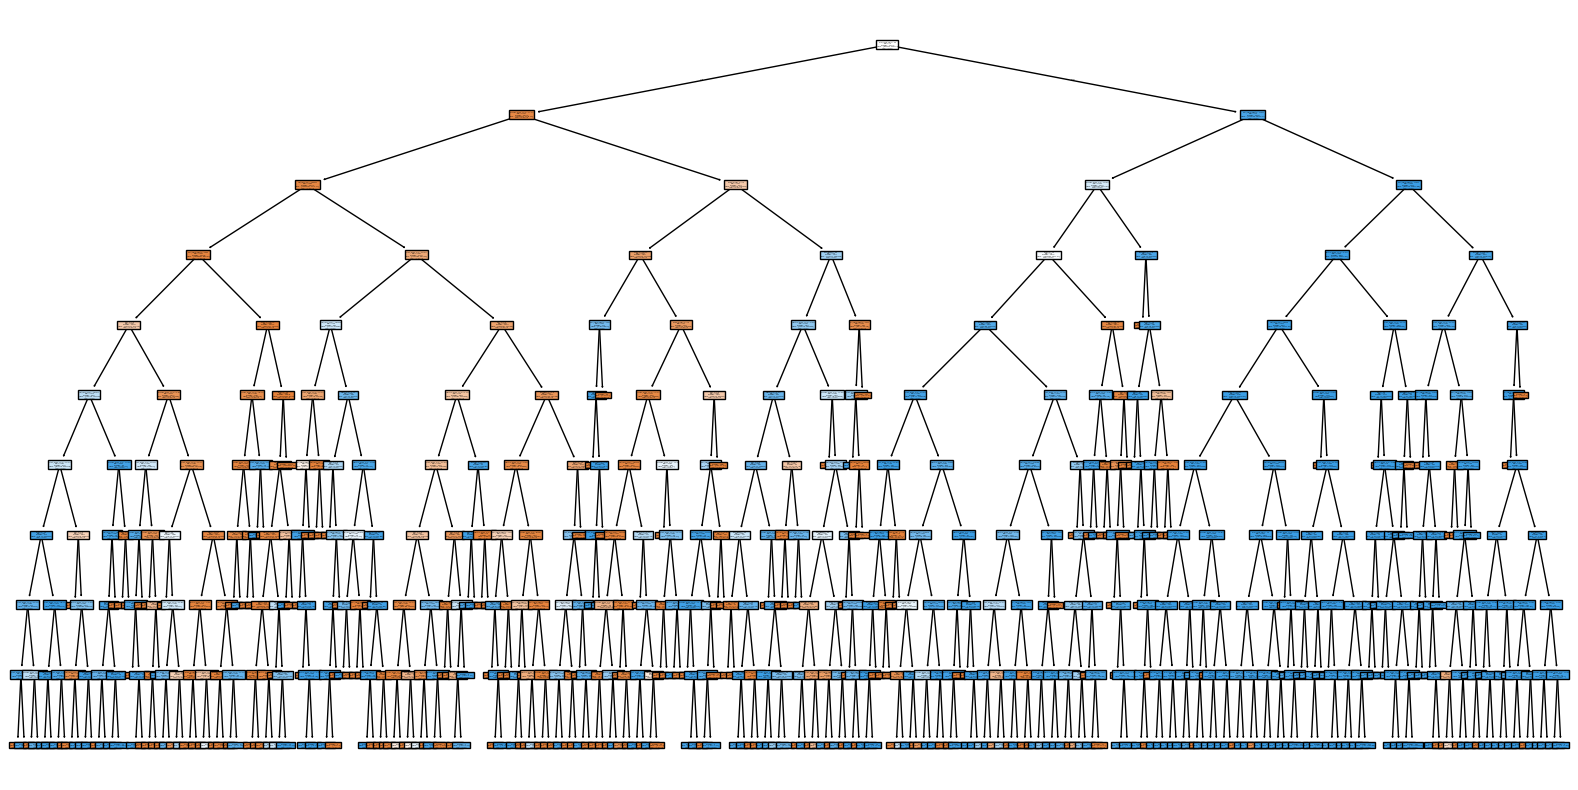

In [7]:
random_forest_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained.")
from sklearn import tree
plt.figure(figsize=(20, 10))
tree.plot_tree(random_forest_model.estimators_[0], filled=True, feature_names=feature_columns, class_names=["No Failure", "Failure"])
plt.show()  

## 8. Evaluate the Models


Logistic Regression
ROC-AUC: 0.9939
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    172023
           1       0.42      0.97      0.59      3277

    accuracy                           0.97    175300
   macro avg       0.71      0.97      0.79    175300
weighted avg       0.99      0.97      0.98    175300



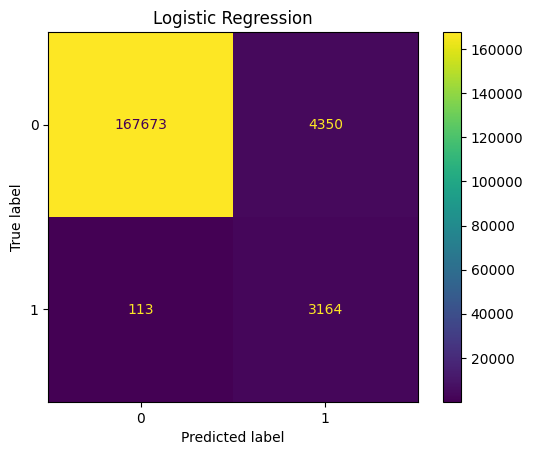

Random Forest
ROC-AUC: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    172023
           1       0.93      1.00      0.96      3277

    accuracy                           1.00    175300
   macro avg       0.96      1.00      0.98    175300
weighted avg       1.00      1.00      1.00    175300



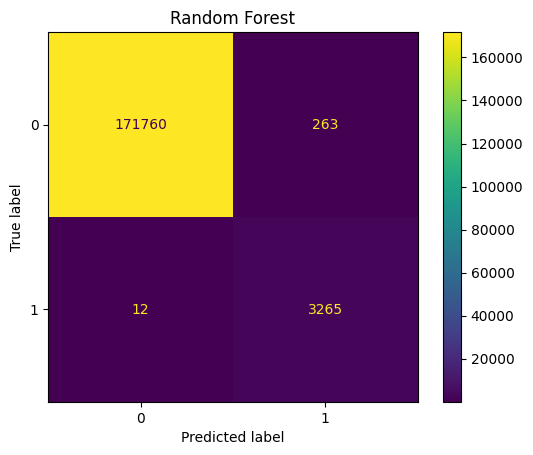

In [8]:
def evaluate_model(model, X_test, y_test, model_name):
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    auc_score = roc_auc_score(y_test, probabilities)

    print(model_name)
    print("ROC-AUC:", round(auc_score, 4))
    print(classification_report(y_test, predictions))

    ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    plt.title(model_name)
    plt.show()

    return auc_score

logistic_auc = evaluate_model(logistic_model, X_test, y_test, "Logistic Regression")
forest_auc = evaluate_model(random_forest_model, X_test, y_test, "Random Forest")

## 9. Compare Test Scores


In [9]:
model_scores = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "roc_auc": [logistic_auc, forest_auc],
})

model_scores.sort_values("roc_auc", ascending=False)

,model,roc_auc
1,Random Forest,0.999840
0,Logistic Regression,0.993856


## 10. Check Train vs Test ROC-AUC


In [10]:
def train_test_auc(model, X_train, y_train, X_test, y_test):
    train_probabilities = model.predict_proba(X_train)[:, 1]
    test_probabilities = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_probabilities)
    test_auc = roc_auc_score(y_test, test_probabilities)

    return train_auc, test_auc

logistic_train_auc, logistic_test_auc = train_test_auc(logistic_model, X_train, y_train, X_test, y_test)
forest_train_auc, forest_test_auc = train_test_auc(random_forest_model, X_train, y_train, X_test, y_test)

overfitting_check = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "train_roc_auc": [logistic_train_auc, forest_train_auc],
    "test_roc_auc": [logistic_test_auc, forest_test_auc],
})

overfitting_check["train_test_gap"] = overfitting_check["train_roc_auc"] - overfitting_check["test_roc_auc"]
overfitting_check


,model,train_roc_auc,test_roc_auc,train_test_gap
0,Logistic Regression,0.991725,0.993856,-0.002131
1,Random Forest,0.999964,0.999840,0.000124


## 11. Feature Importance


In [11]:
feature_importance = pd.Series(random_forest_model.feature_importances_, index=feature_columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(15)

error_count_24h       0.334672
days_since_maint      0.269625
rotate_mean_24h       0.087686
volt_mean_24h         0.073172
vibration_mean_24h    0.040232
vibration_mean_3h     0.031355
rotate_mean_3h        0.030830
pressure_mean_3h      0.029140
pressure_mean_24h     0.028408
month                 0.016600
volt_mean_3h          0.015310
vibration             0.006104
age                   0.005840
hour                  0.005367
pressure              0.005277
dtype: float64

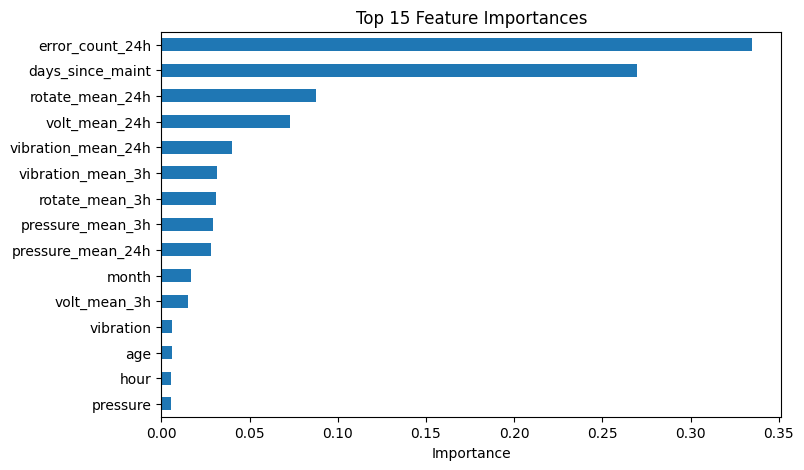

In [12]:
feature_importance.head(15).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

## 12. Save the Best Model


In [13]:
if forest_auc >= logistic_auc:
    best_model = random_forest_model
    best_model_name = "Random Forest"
else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"

joblib.dump(best_model, DATA_DIR / "model.pkl")
joblib.dump(feature_columns, DATA_DIR / "feature_columns.pkl")

print("Best model:", best_model_name)
print("Saved model.pkl")
print("Saved feature_columns.pkl")

Best model: Random Forest
Saved model.pkl
Saved feature_columns.pkl


## Notebook Complete
